Telecom Network & Customer Experience Analytics.

Business Context: A telecom company is facing increasing customer complaints, delayed payments, and unclear
impact of network quality on customer retention. Leadership needs data-driven insights to prioritize network
investments and reduce churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
customers=pd.read_excel(r"C:\Users\Sarma\Documents\DA INTERNSHIP PROJECTS\Telecom_DataSet.xlsx",sheet_name="customers")

In [3]:
network_usage=pd.read_excel(r"C:\Users\Sarma\Documents\DA INTERNSHIP PROJECTS\Telecom_DataSet.xlsx",sheet_name="network_usage")

In [4]:
network_issues=pd.read_excel(r"C:\Users\Sarma\Documents\DA INTERNSHIP PROJECTS\Telecom_DataSet.xlsx",sheet_name="network_issues")

In [5]:
billing=pd.read_excel(r"C:\Users\Sarma\Documents\DA INTERNSHIP PROJECTS\Telecom_DataSet.xlsx",sheet_name="billing")

Creating customer risk score using functions and if-else

In [6]:
issue_count=network_issues.groupby("customer_id")["issue_id"].count().reset_index()
issue_count.rename(columns={"issue_id":"complaint_count"},inplace=True)

In [7]:
df=customers.merge(issue_count,on="customer_id",how="left")
df=df.merge(billing,on="customer_id",how="left")
df["complaint_count"].fillna(0)

0       12.0
1       12.0
2       12.0
3       12.0
4       12.0
        ... 
5332    10.0
5333    10.0
5334    10.0
5335    10.0
5336    10.0
Name: complaint_count, Length: 5337, dtype: float64

In [8]:
def risk_score(complaints,payment):
    if complaints>5 and payment=="Delayed":
        return "High risk"
    elif complaints>2:
        return "Meduim Risk"
    else:
        return "Low Risk"

In [9]:
df["risk_score"]=df.apply(lambda x:risk_score(x["complaint_count"],x["payment_status"]),axis=1)


In [10]:
df.head()

,customer_id,customer_type,age,city,signup_date,Month,Year,complaint_count,bill_id,bill_month,bill_amount,payment_status,risk_score
0,1,Prepaid,34,Kolkata,2020-10-21,10,2020,12.0,30562,2023-09-30,1580,Paid,Meduim Risk
1,1,Prepaid,34,Kolkata,2020-10-21,10,2020,12.0,30594,2023-09-30,600,Paid,Meduim Risk
2,1,Prepaid,34,Kolkata,2020-10-21,10,2020,12.0,30810,2023-12-10,1077,Failed,Meduim Risk
3,1,Prepaid,34,Kolkata,2020-10-21,10,2020,12.0,31551,2023-12-22,1884,Paid,Meduim Risk
4,1,Prepaid,34,Kolkata,2020-10-21,10,2020,12.0,32175,2023-01-18,1311,Delayed,High risk


Using lambda for heavy usage flags

In [11]:
network_usage["Heavy_User"]=\
network_usage["data_used_gb"].apply(
    lambda x:
    "Heavy User"
    if x>3
    else "Normal User")
network_usage.head()

,usage_id,customer_id,usage_date,data_used_gb,call_minutes,network_type,Usage_Status,Heavy_User
0,10001,288,2023-09-20,2.01,49,4G,Normal,Normal User
1,10002,167,2023-10-25,2.50,134,5G,Normal,Normal User
2,10003,109,2024-04-29,0.74,117,4G,Normal,Normal User
3,10004,494,2022-02-19,7.42,59,4G,High Usage,Heavy User
4,10005,36,2023-05-17,0.47,124,5G,Normal,Normal User


Performing exploratory analysis and visualizations

In [12]:
customers.info()
network_usage.info()
network_issues.info()
billing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customer_id    500 non-null    int64         
 1   customer_type  500 non-null    object        
 2   age            500 non-null    int64         
 3   city           500 non-null    object        
 4   signup_date    500 non-null    datetime64[ns]
 5   Month          500 non-null    int64         
 6   Year           500 non-null    int64         
dtypes: datetime64[ns](1), int64(4), object(2)
memory usage: 27.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8316 entries, 0 to 8315
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   usage_id      8316 non-null   int64         
 1   customer_id   8316 non-null   int64         
 2   usage_date    8316 non-null   datetime64[ns]
 3   data_u

In [13]:
customers.isnull().sum()

customer_id      0
customer_type    0
age              0
city             0
signup_date      0
Month            0
Year             0
dtype: int64

In [14]:
network_usage.isnull().sum()

usage_id        0
customer_id     0
usage_date      0
data_used_gb    0
call_minutes    0
network_type    0
Usage_Status    0
Heavy_User      0
dtype: int64

In [15]:
network_issues.isnull().sum()

issue_id               0
customer_id            0
issue_date             0
issue_type             0
resolution_time_hrs    0
resolved               0
city_issue             0
dtype: int64

In [16]:
billing.isnull().sum()

bill_id           0
customer_id       0
bill_month        0
bill_amount       0
payment_status    0
dtype: int64

In [17]:
network_usage.describe()

,usage_id,customer_id,usage_date,data_used_gb,call_minutes
count,8316.000000,8316.000000,8316,8316.000000,8316.000000
mean,12487.504329,251.652357,2023-03-27 15:54:27.532467712,2.456225,148.982804
min,10001.000000,1.000000,2022-01-01 00:00:00,0.000000,0.000000
25%,11040.000000,126.000000,2022-08-09 00:00:00,0.720000,74.000000
50%,12079.500000,251.000000,2023-03-31 00:00:00,1.690000,147.000000
75%,13921.250000,380.000000,2023-11-09 00:00:00,3.400000,224.000000
max,16000.000000,500.000000,2024-06-18 00:00:00,20.070000,299.000000
std,1723.693320,144.512979,NaN,2.447710,86.232206


Customers city-wise analysis

In [18]:
customers["city"].value_counts()

city
Delhi        93
Chennai      91
Hyderabad    88
Bangalore    87
Kolkata      76
Mumbai       65
Name: count, dtype: int64

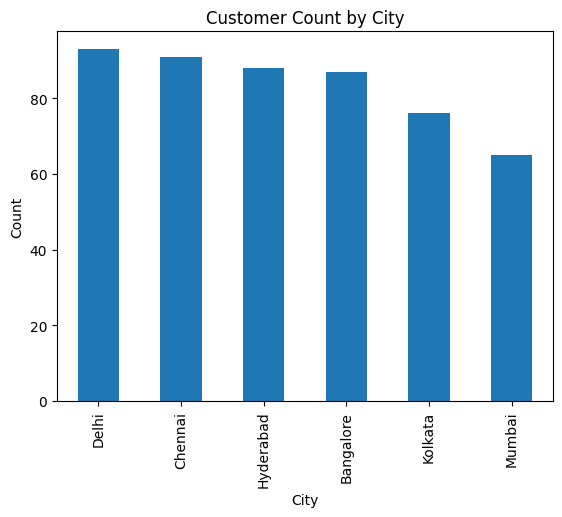

In [19]:
customers["city"].value_counts().plot(kind="bar")
plt.title("Customer Count by City")
plt.xlabel("City")
plt.ylabel("Count")
plt.show()

Ranking:

Delhi (~93)
Chennai (~91)
Hyderabad (~88)
Bangalore (~87)
Kolkata (~76)
Mumbai (~65)

Interpretation:

Customer distribution across cities is fairly balanced.
Delhi has the largest representation.
Mumbai appears underrepresented.

Could indicate:

sampling differences
market penetration differences

Network issue analysis

In [20]:
network_issues["issue_type"].value_counts()

issue_type
Call Drop        1961
No Signal        1936
Slow Internet    1926
Name: count, dtype: int64

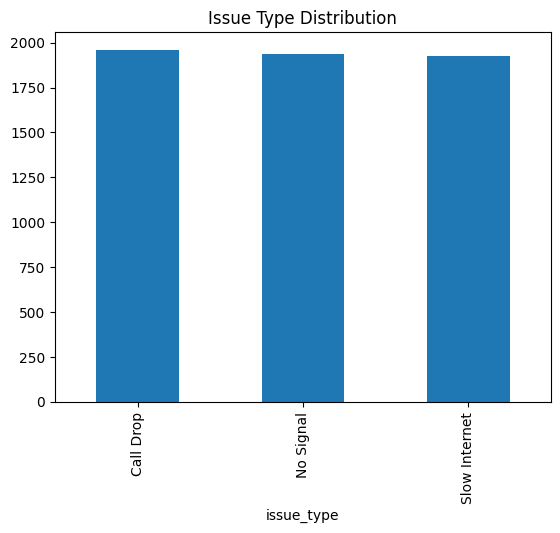

In [21]:
network_issues["issue_type"].value_counts().plot(kind="bar")
plt.title("Issue Type Distribution")
plt.show()

Three complaint categories: Call Drop, No Signal, and Slow Internet.
All three are almost equally distributed, around 1900–1950 cases each.
Interpretation:
Customer issues are spread evenly.
No single problem dominates.
Service quality challenges appear balanced across voice and internet performance.

Month-wise complaints trend

In [22]:
network_issues["issue_date"]=pd.to_datetime(
network_issues["issue_date"]
)

monthly_issues=network_issues.groupby(
network_issues["issue_date"].dt.month
)["issue_id"].count()

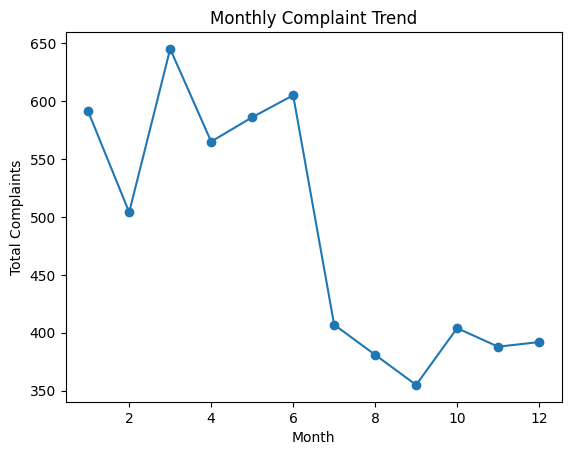

In [23]:
monthly_issues.plot(kind="line",marker="o")
plt.title("Monthly Complaint Trend")
plt.xlabel("Month")
plt.ylabel("Total Complaints")
plt.show()

Complaints are high from Month 1–6 (~500–650).
Sharp decline after Month 6, dropping near 350–400.
Interpretation:
Something improved after Month 6:
network upgrade,
infrastructure optimization,
issue resolution campaign,
seasonal effect.
The sudden drop suggests a major operational change.

Key insight:

Complaints reduced by roughly 35–40% in the second half of the year.

Data usage analysis

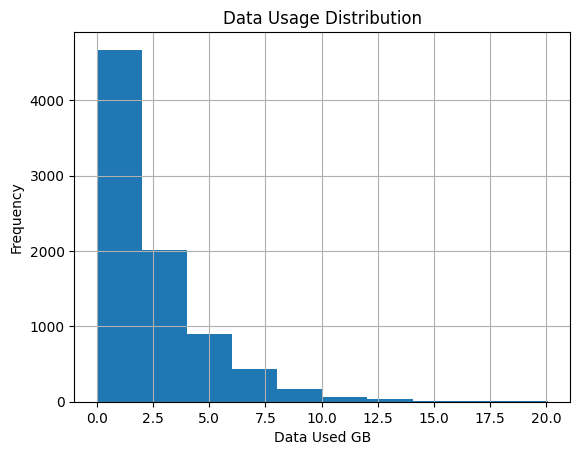

In [24]:
network_usage["data_used_gb"].hist()
plt.xlabel("Data Used GB")
plt.ylabel("Frequency")
plt.title("Data Usage Distribution")
plt.show()

Strong right-skewed distribution.
Most users consume low data volumes (0–4 GB).
Very few users consume 10–20 GB.

Interpretation:

Majority are average/light users.
Small segment consumes very high data.

This is typical in telecom:

A small percentage of customers often generates a large share of traffic.

Payment status analysis

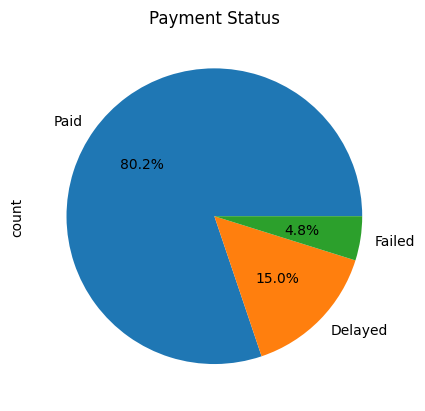

In [25]:
billing["payment_status"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Payment Status")
plt.show()

Paid: 80.2%
Delayed: 15%
Failed: 4.8%

Interpretation:

Most customers pay successfully.
Around 1 in 5 payments has an issue.

Potential concern:
Delayed + failed payments = 19.8%

This may affect:

revenue flow
churn risk
customer retention

Network Type Analysis (4G vs 5G)

In [26]:
network_usage["network_type"].value_counts()

network_type
4G    5737
5G    2579
Name: count, dtype: int64

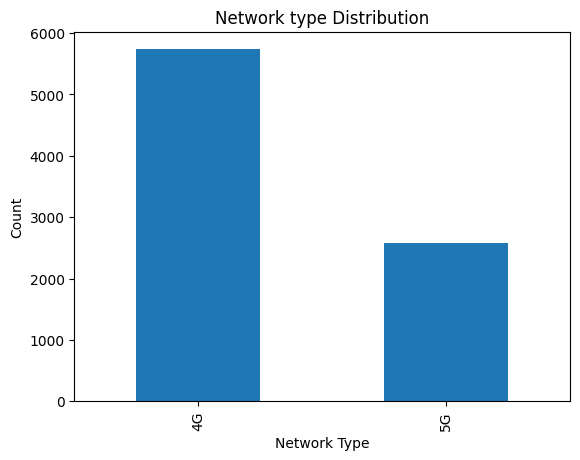

In [27]:
network_usage["network_type"].value_counts().plot(kind="bar")
plt.title("Network type Distribution")
plt.ylabel("Count")
plt.xlabel("Network Type")
plt.show()

4G users ≈ 5750
5G users ≈ 2600

Interpretation:

4G still dominates.
5G adoption is growing but not yet mainstream.

Possible reasons:

limited 5G coverage
device compatibility
cost of 5G plans

Heavy User Analysis

In [28]:
network_usage["Heavy_User"].value_counts()

Heavy_User
Normal User    5889
Heavy User     2427
Name: count, dtype: int64

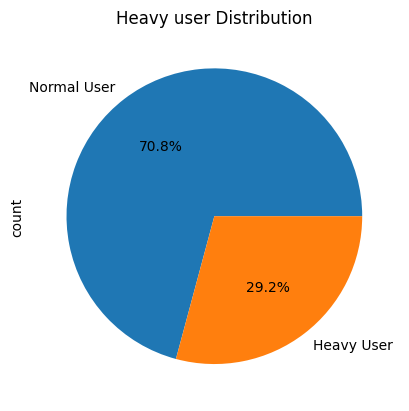

In [29]:
network_usage["Heavy_User"].value_counts().plot(kind="pie",autopct="%1.1f%%")
plt.title("Heavy user Distribution")
plt.show()

Normal users: 70.8%
Heavy users: 29.2%

Interpretation:

Roughly 3 out of 10 users are heavy consumers.

This matters because heavy users:

consume more bandwidth
influence network load
may need premium plans

Resolution Time Analysis

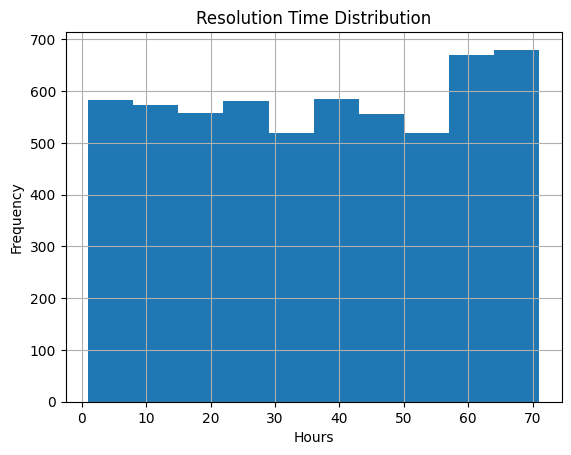

In [30]:
network_issues["resolution_time_hrs"].hist()
plt.title("Resolution Time Distribution")
plt.xlabel("Hours")
plt.ylabel("Frequency")
plt.show()

Resolution times spread between 0–72 hours
Distribution appears relatively uniform.

Interpretation:

Support cases are being resolved at varying speeds.
No strong clustering around quick resolution.

Possible concern:
Some customers wait nearly 3 days.

Improvement opportunity:
Reduce average resolution time and standardize support response.

Average Data Usage by Network Type

In [31]:
network_usage.groupby("network_type")["data_used_gb"].mean()

network_type
4G    2.468032
5G    2.429961
Name: data_used_gb, dtype: float64

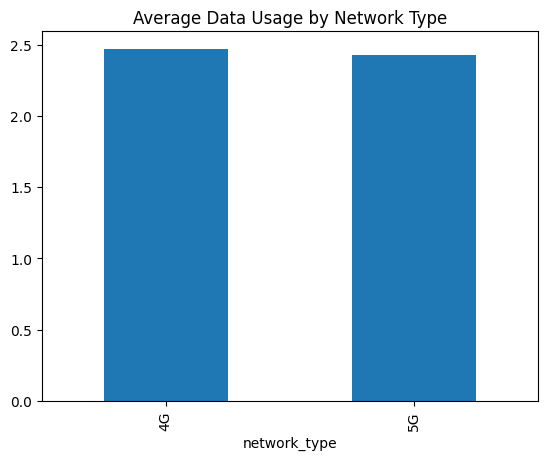

In [32]:
network_usage.groupby("network_type")["data_used_gb"].mean().plot(kind="bar")
plt.title("Average Data Usage by Network Type")
plt.show()

4G ≈ 2.47 GB
5G ≈ 2.43 GB

Interpretation:

Data consumption between 4G and 5G users is almost identical.
5G users are not consuming significantly more data.

Interesting finding:
Normally 5G users consume more due to higher speeds.

Possible reasons:

early-stage adoption
similar user behavior
limited 5G usage scenarios

Overall Business Story

This dataset suggests:

Strengths

Complaint volume reduced over time.
High payment success rate.
Balanced issue categories.

Potential concerns

Delayed/failed payments near 20%.
Resolution time can be long.
5G adoption still low.
Heavy users may create network strain.

Action recommendations

Investigate what caused the complaint drop and replicate it.
Improve payment reliability.
Reduce ticket resolution times.
Encourage migration from 4G to 5G.
Create targeted plans for heavy users.